# Methodology 

The analysis follows a structured exploratory data analysis (EDA) workflow:

1. Data Overview  
2. Data Quality Assessment  
3. Data Cleaning  
4. Exploratory Data Analysis (EDA)
   - Fraud distribution
   - Feature-level analysis
   - Behavioural pattern analysis
5. Multivariate Analysis
6. Summary of Key Findings

The goal of this analysis is to identify behavioural indicators associated with fraudulent transactions.


# Data Overview

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
df = pd.read_csv('FraudShield_Banking_Data.csv')

df.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


# Data Quality Check

In [16]:
print('Dataset shape', df.shape)

Dataset shape (50000, 25)


In [17]:
list(df.columns)

['Transaction_ID',
 'Customer_ID',
 'Transaction_Amount (in Million)',
 'Transaction_Time',
 'Transaction_Date',
 'Transaction_Type',
 'Merchant_ID',
 'Merchant_Category',
 'Transaction_Location',
 'Customer_Home_Location',
 'Distance_From_Home',
 'Device_ID',
 'IP_Address',
 'Card_Type',
 'Account_Balance (in Million)',
 'Daily_Transaction_Count',
 'Weekly_Transaction_Count',
 'Avg_Transaction_Amount (in Million)',
 'Max_Transaction_Last_24h (in Million)',
 'Is_International_Transaction',
 'Is_New_Merchant',
 'Failed_Transaction_Count',
 'Unusual_Time_Transaction',
 'Previous_Fraud_Count',
 'Fraud_Label']

In [18]:
df.isnull().sum()

Transaction_ID                            3
Customer_ID                              10
Transaction_Amount (in Million)           9
Transaction_Time                          9
Transaction_Date                          3
Transaction_Type                          4
Merchant_ID                               7
Merchant_Category                         9
Transaction_Location                      6
Customer_Home_Location                    4
Distance_From_Home                        2
Device_ID                                 9
IP_Address                                6
Card_Type                                 3
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Weekly_Transaction_Count                  5
Avg_Transaction_Amount (in Million)       9
Max_Transaction_Last_24h (in Million)     4
Is_International_Transaction              4
Is_New_Merchant                           5
Failed_Transaction_Count                 11
Unusual_Time_Transaction        

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  str    
 4   Transaction_Date                       49997 non-null  str    
 5   Transaction_Type                       49996 non-null  str    
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  str    
 8   Transaction_Location                   49994 non-null  str    
 9   Customer_Home_Location                 49996 non-null  str    
 10  Distance_From_Home                     49998 non-null  float64
 11  Device_ID    

In [20]:
df.describe()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Merchant_ID,Distance_From_Home,Device_ID,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count
count,49997.000000,49990.000000,49991.000000,49993.000000,49998.000000,49991.000000,49991.000000,49991.000000,49995.000000,49991.000000,49996.000000,49989.000000,49997.000000
mean,550400.968898,54869.720744,4.999880,54951.375913,300.098564,552563.600088,20.993179,3.999460,12.520032,2.989098,5.016781,0.992798,0.500130
std,259677.602349,26052.824933,2.582025,25983.342481,172.848263,260186.451027,10.685467,2.002833,6.910709,1.413400,2.572913,0.816081,0.500005
min,100043.000000,10005.000000,1.000000,10001.000000,1.000000,100053.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,324445.000000,32259.250000,3.000000,32545.000000,150.000000,327643.500000,12.000000,2.000000,7.000000,2.000000,3.000000,0.000000,0.000000
50%,552115.000000,54720.500000,5.000000,54935.000000,301.000000,553372.000000,21.000000,4.000000,13.000000,3.000000,5.000000,1.000000,1.000000
75%,775942.000000,77542.000000,7.000000,77341.000000,449.000000,779903.500000,30.000000,6.000000,18.000000,4.000000,7.000000,2.000000,1.000000
max,999992.000000,99996.000000,9.000000,99996.000000,599.000000,999989.000000,39.000000,7.000000,24.000000,5.000000,9.000000,2.000000,1.000000


In [21]:
df['Fraud_Label'].value_counts()
df['Fraud_Label'].value_counts(normalize = True) * 100

Fraud_Label
Normal    95.153612
Fraud      4.846388
Name: proportion, dtype: float64

# Data Cleaning

In [22]:
df = df.dropna()
df.isnull().sum()

Transaction_ID                           0
Customer_ID                              0
Transaction_Amount (in Million)          0
Transaction_Time                         0
Transaction_Date                         0
Transaction_Type                         0
Merchant_ID                              0
Merchant_Category                        0
Transaction_Location                     0
Customer_Home_Location                   0
Distance_From_Home                       0
Device_ID                                0
IP_Address                               0
Card_Type                                0
Account_Balance (in Million)             0
Daily_Transaction_Count                  0
Weekly_Transaction_Count                 0
Avg_Transaction_Amount (in Million)      0
Max_Transaction_Last_24h (in Million)    0
Is_International_Transaction             0
Is_New_Merchant                          0
Failed_Transaction_Count                 0
Unusual_Time_Transaction                 0
Previous_Fr

# Exploratory Data Analysis

### Fraud Distribution

Fraud Rate: 4.85%


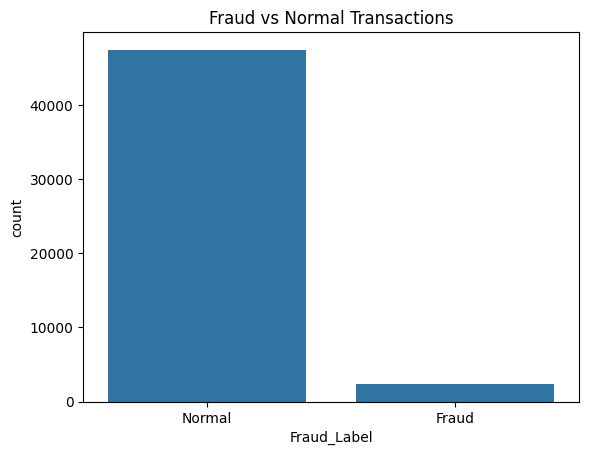

In [23]:
fraud_rate = df['Fraud_Label'].value_counts(normalize=True)['Fraud'] * 100
print(f"Fraud Rate: {fraud_rate:.2f}%")

sns.countplot(x = "Fraud_Label", data = df)
plt.title("Fraud vs Normal Transactions")
plt.show()

Fraudulent transactions represnt *4.85% of all transactions*, Indicating the suggestion that there is a high imbalance in the Dataset

### Does Transaction Amount Indicate Fraud?

In [24]:
df.groupby("Fraud_Label")["Transaction_Amount (in Million)"].agg(["mean", "median", "max"])


,mean,median,max
Fraud_Label,,,
Fraud,4.995035,5.0,9.0
Normal,4.999852,5.0,9.0


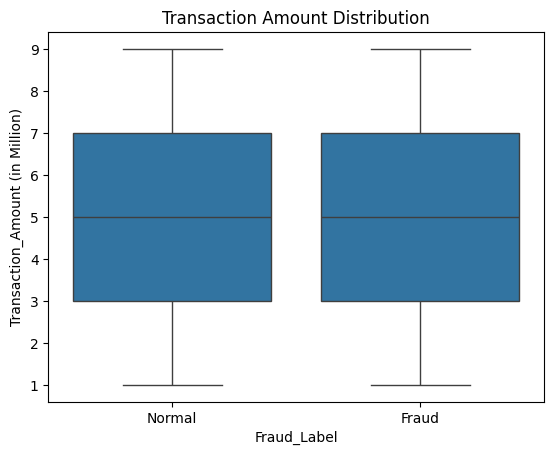

In [25]:
sns.boxplot(x="Fraud_Label", y="Transaction_Amount (in Million)", data=df)
plt.title("Transaction Amount Distribution")
plt.show()

Transaction amount distributions for fraud and normal transactions appear highly similar, with nearly identical medians and ranges. This suggests transaction value alone is not a strong indicator of fraudulent behaviour.

### International transaction & Merchant behaviour vs Fraud

In [28]:
pd.crosstab(
    [df['Is_New_Merchant'], df['Is_International_Transaction']],
    df['Fraud_Label'],
    normalize='index'
)

Fraud_Label                                      Fraud    Normal
Is_New_Merchant Is_International_Transaction                    
No              No                            0.037210  0.962790
                Yes                           0.058772  0.941228
Yes             No                            0.033833  0.966167
                Yes                           0.063959  0.936041

Fraud rates icrease noticeably for international Transactions, rising approximately 3-4% for domestic fraud whilst interntional transactions was around 6%. The merchant novelty appears to have minimal impac on Fraud List indendently The highest fraud rate occurs when transactions are both international and involve a new merchant, though this increase is modest relative to the international transaction effect.

### Distance From Home Analysis

In [7]:
df.groupby("Fraud_Label")["Distance_From_Home"].median()

Fraud_Label
Fraud     289.0
Normal    301.0
Name: Distance_From_Home, dtype: float64

<Axes: xlabel='Distance_From_Home', ylabel='Density'>

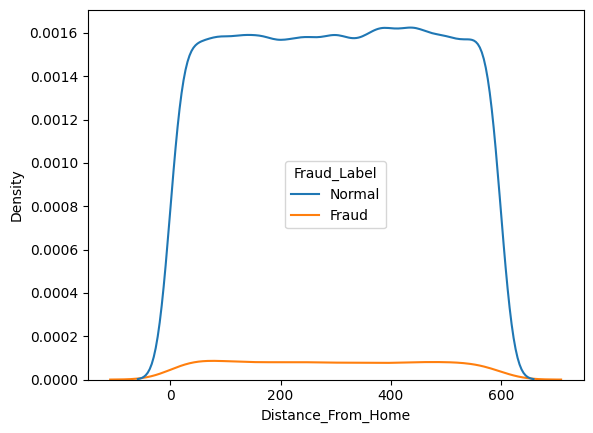

In [10]:
sns.kdeplot(data=df, x="Distance_From_Home", hue="Fraud_Label")

Distance from home shows nearly identical distributions between fraudulent and normal transactions. Both the median values and density distributions overlap substantially, indicating that transaction distance alone is not a meaningful predictor of fraud within this dataset.

# Multivariate Analysis 

### Which variables are most associated with fraud

In [12]:
df['Fraud_Label_Num'] = df['Fraud_Label'].map({'Normal':0, 'Fraud':1})
corr_matrix = df.corr(numeric_only=True)
fraud_corr = corr_matrix['Fraud_Label_Num'].sort_values(ascending=False)
fraud_corr

Fraud_Label_Num                          1.000000
Max_Transaction_Last_24h (in Million)    0.007003
Previous_Fraud_Count                     0.004878
Merchant_ID                              0.004349
Customer_ID                              0.004007
Transaction_ID                           0.000911
Daily_Transaction_Count                 -0.000172
Device_ID                               -0.000249
Weekly_Transaction_Count                -0.000872
Transaction_Amount (in Million)         -0.001032
Failed_Transaction_Count                -0.001428
Account_Balance (in Million)            -0.006131
Avg_Transaction_Amount (in Million)     -0.006303
Distance_From_Home                      -0.010564
Name: Fraud_Label_Num, dtype: float64

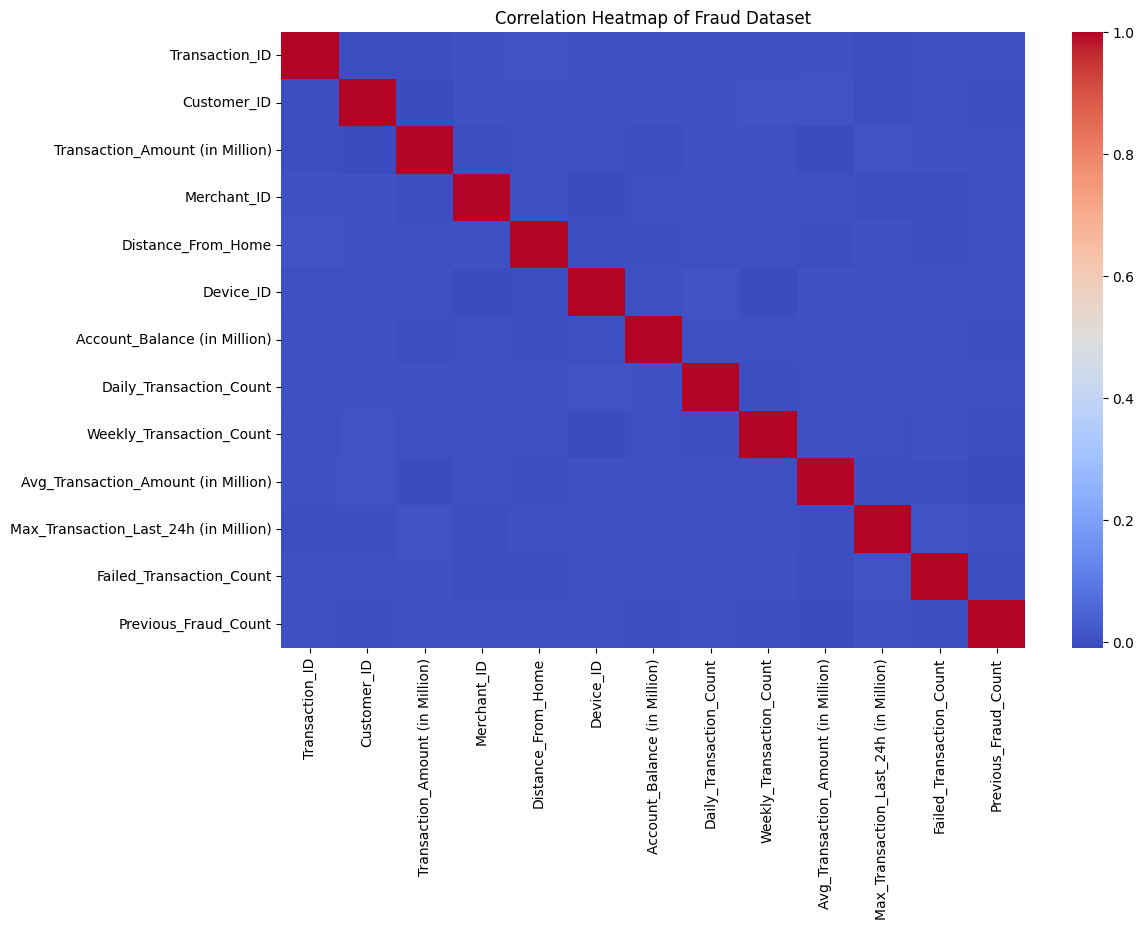

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Fraud Dataset")
plt.show()

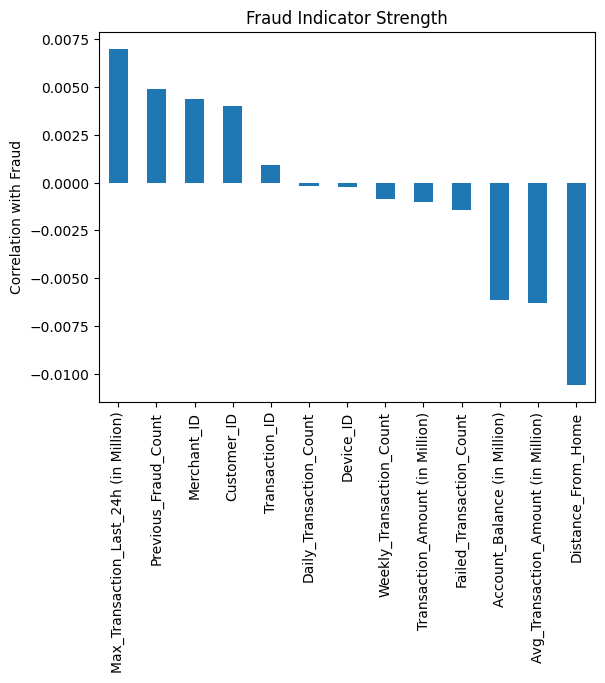

In [13]:
fraud_corr.drop('Fraud_Label_Num').plot(kind='bar')
plt.title("Fraud Indicator Strength")
plt.ylabel("Correlation with Fraud")
plt.show()

 # Key Findings

### Fraud prevalence

Fraudulent transactions represent approximately 4–5% of total transactions, indicating a moderately imbalanced dataset. This distribution is typical in fraud detection problems where fraudulent behaviour occurs relatively infrequently compared to legitimate activity.

### Transaction amount

Analysis of transaction amount shows no meaningful difference between fraudulent and legitimate transactions. Both the statistical summaries and distribution visualisations indicate very similar medians and ranges. This suggests that transaction value alone is not a strong indicator of fraudulent activity in this dataset.

### Distance from home

Distance from the customer’s home location also shows very similar distributions between fraud and normal transactions. The median values differ only slightly and the density curves overlap substantially. This indicates that transaction distance does not meaningfully distinguish fraudulent behaviour in this dataset.

### International transactions

International transactions demonstrate noticeably higher fraud rates compared to domestic transactions.

Domestic transactions show fraud rates around 3–4%

International transactions show fraud rates around 6%

This suggests that international transaction context is a meaningful behavioural indicator of fraud risk.

### Merchant novelty

Transactions involving new merchants do not show a strong independent relationship with fraud risk. Fraud rates remain similar between transactions with new merchants and those with previously known merchants.

### Combined behavioural signals

When analysing behavioural factors together, the highest fraud rates occur when transactions are both international and involve a new merchant. However, the increase appears to be primarily driven by the international transaction factor rather than merchant novelty alone.

## Overall conclusion

### The analysis suggests that fraud in this dataset is more strongly associated with behavioural context rather than transaction magnitude or location distance. Variables such as international transaction status appear to be more informative indicators of fraud risk than transaction size or distance from the customer's home